In [178]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Credit Risk - Exploratory Data Analysis

This notebook explores the dataset used for predicting credit default risk.

We start by loading the dataset and inspecting its structure

In [179]:
labels = pd.read_excel("../data/raw/Data Dictionary.xls")
labels

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Variable Name,Description,Type
1,SeriousDlqin2yrs,Person experienced 90 days past due delinquenc...,Y/N
2,RevolvingUtilizationOfUnsecuredLines,Total balance on credit cards and personal lin...,percentage
3,age,Age of borrower in years,integer
4,NumberOfTime30-59DaysPastDueNotWorse,Number of times borrower has been 30-59 days p...,integer
5,DebtRatio,"Monthly debt payments, alimony,living costs di...",percentage
6,MonthlyIncome,Monthly income,real
7,NumberOfOpenCreditLinesAndLoans,Number of Open loans (installment like car loa...,integer
8,NumberOfTimes90DaysLate,Number of times borrower has been 90 days or m...,integer
9,NumberRealEstateLoansOrLines,Number of mortgage and real estate loans inclu...,integer


In [180]:
df = pd.read_csv("../data/raw/cs-training.csv")

First rows of the dataset to understand structure

In [181]:
df.head(n=10)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
5,6,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1.0
6,7,0,0.305682,57,0,5710.000000,NaN,8,0,3,0,0.0
7,8,0,0.754464,39,0,0.209940,3500.0,8,0,0,0,0.0
8,9,0,0.116951,27,0,46.000000,NaN,2,0,0,0,NaN
9,10,0,0.189169,57,0,0.606291,23684.0,9,0,4,0,2.0


Let’s take a look at our list of variables

In [182]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  NumberOfDep

Here we can see that all variables are of numeric type and only a few columns got missing values. They will be dealt with later.

Basic statistics may help us understand the distributions and detect anomalies


<Axes: >

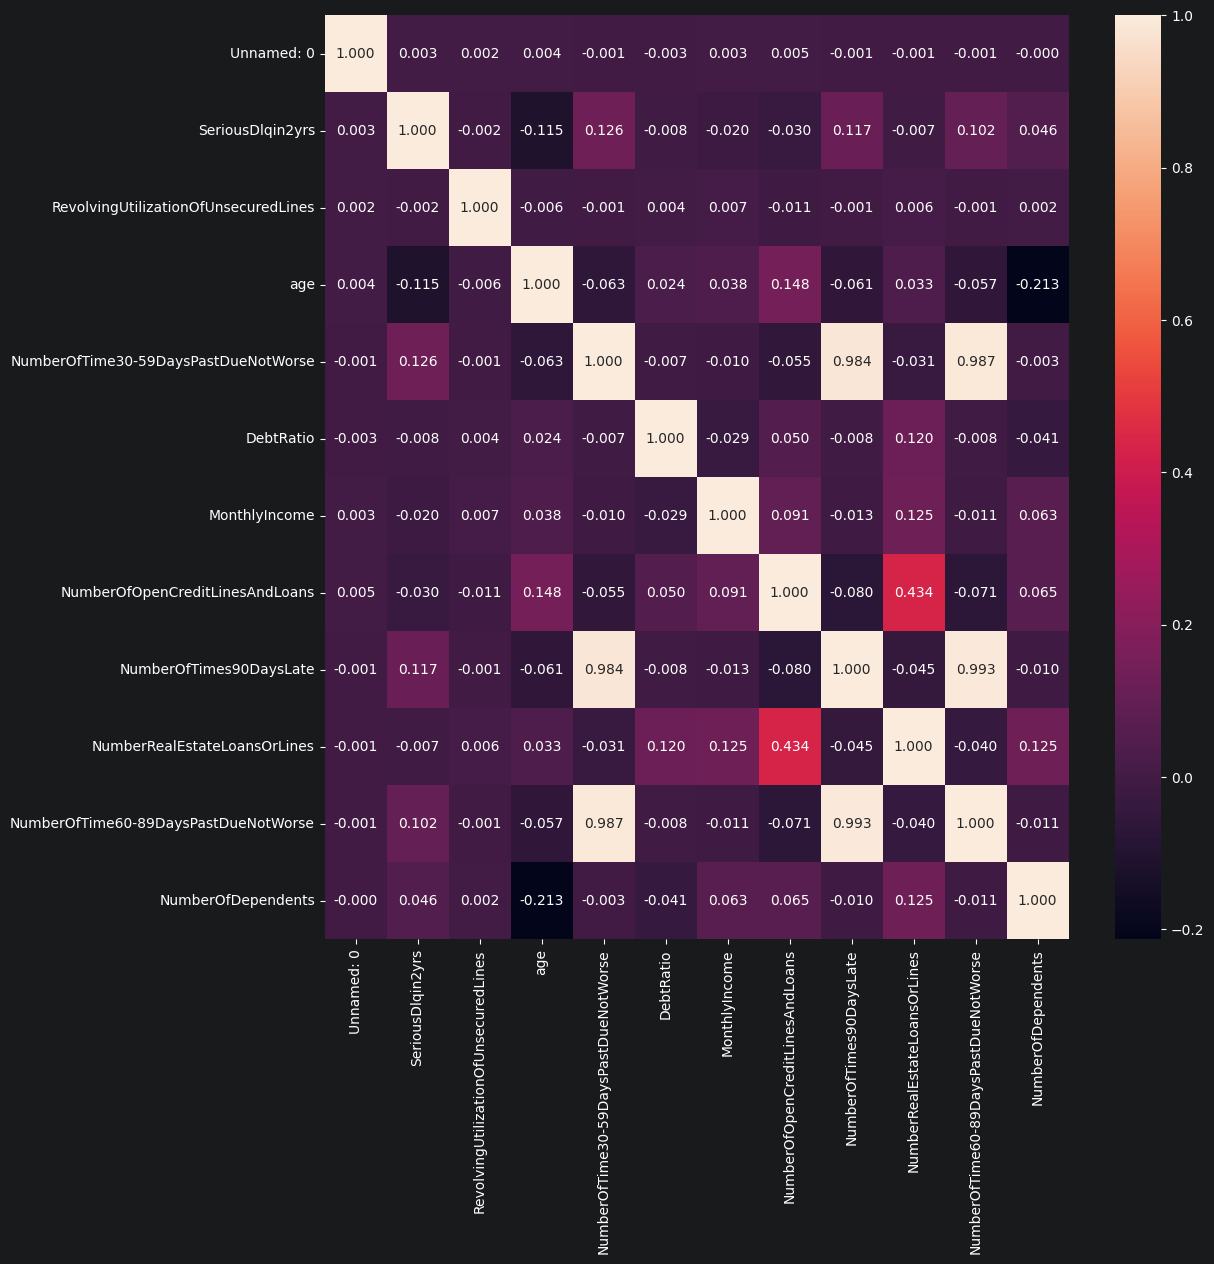

In [183]:
corr = df.corr()
plt.figure(figsize=(12,12))
sns.heatmap(corr, annot=True, fmt='.3f')

In [184]:
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


If we take a look at column 'SeriousDlqin2yrs', we can see that there are imbalanced classes. We will also deal with this later.

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64


<Axes: xlabel='SeriousDlqin2yrs', ylabel='count'>

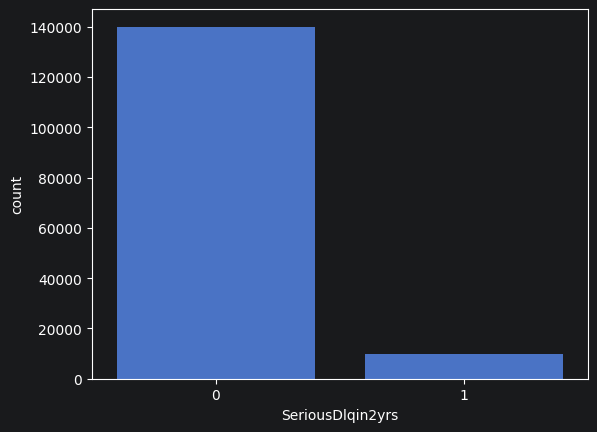

In [185]:
print(df['SeriousDlqin2yrs'].value_counts())
sns.countplot(x=df['SeriousDlqin2yrs'])

Given the fact that the legal age is 18 and there are values <18 in the 'age' column, we should handle them.

In [186]:
df.loc[df["MonthlyIncome"] == -1]

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents


There is only one record with an age below the legal limit. Since the other values in this row are complete, we will replace it with the median age.

In [187]:
df.loc[df['age'] == 0, 'age'] = df['age'].median()

The columns ‘NumberOfTime30-59DaysPastDueNotWorse’, ‘NumberOfTime60-89DaysPastDueNotWorse’, and ‘NumberOfTimes90DaysLate’ are highly correlated. Therefore, using them separately for model training may not improve predictive performance. One way to address this issue is to combine them into a single binary feature called ‘WasEverLate’. This feature is set to 1 if the sum of these columns is greater than or equal to 1, and 0 otherwise.

The columns ‘NumberOfOpenCreditLinesAndLoans’ and ‘NumberRealEstateLoansOrLines’ are also correlated, though not as strongly. In this case, we apply a different approach by creating a new binary feature, ‘DebtOnAssets’. This feature takes the value 1 if the sum of these two columns is greater than or equal to 6, and 0 otherwise.

In [188]:
df = df.rename(columns = {df.columns[0]:'ID'})

df['WasEverLate'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] +
    df['NumberOfTime60-89DaysPastDueNotWorse'] +
    df['NumberOfTimes90DaysLate']
)
df['WasEverLate'] = (df['WasEverLate'] >= 1).astype(np.int64)

df['DebtOnAssets'] = (
    df['NumberOfOpenCreditLinesAndLoans'] +
    df['NumberRealEstateLoansOrLines']
)
df['DebtOnAssets'] = (df['DebtOnAssets'] >= 6).astype(np.int64)


Additionally, individuals can be categorized based on age. Since gender information is unavailable, it is reasonable to define a senior as a person aged 60 or older. Using this threshold, we can create categories such as ‘working’ and ‘senior’.

The ‘MonthlyIncome’ column has a relatively high number of missing values (approximately 20%). The newly created age classes will help us achieve more accurate imputations for income, as they will be used to compute the mean monthly income within each group.

There are also some null values in the ‘NumberOfDependents’ column. The safest approach to address this would be filling these cells with 0

In [189]:
working = df.loc[(df['age'] >= 18) & (df['age'] < 60)]
senior = df.loc[df['age'] > 60]
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(-1).astype(np.float64)

df.loc[(df['MonthlyIncome'] == -1) & ((df['age'] >= 18) & (df['age'] < 60)), 'MonthlyIncome'] =  working['MonthlyIncome'].mean()
df.loc[(df['MonthlyIncome'] == -1) & (df['age'] >= 60), 'MonthlyIncome'] =  senior['MonthlyIncome'].mean()

df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0).astype(np.int64)

Check results

<Axes: >

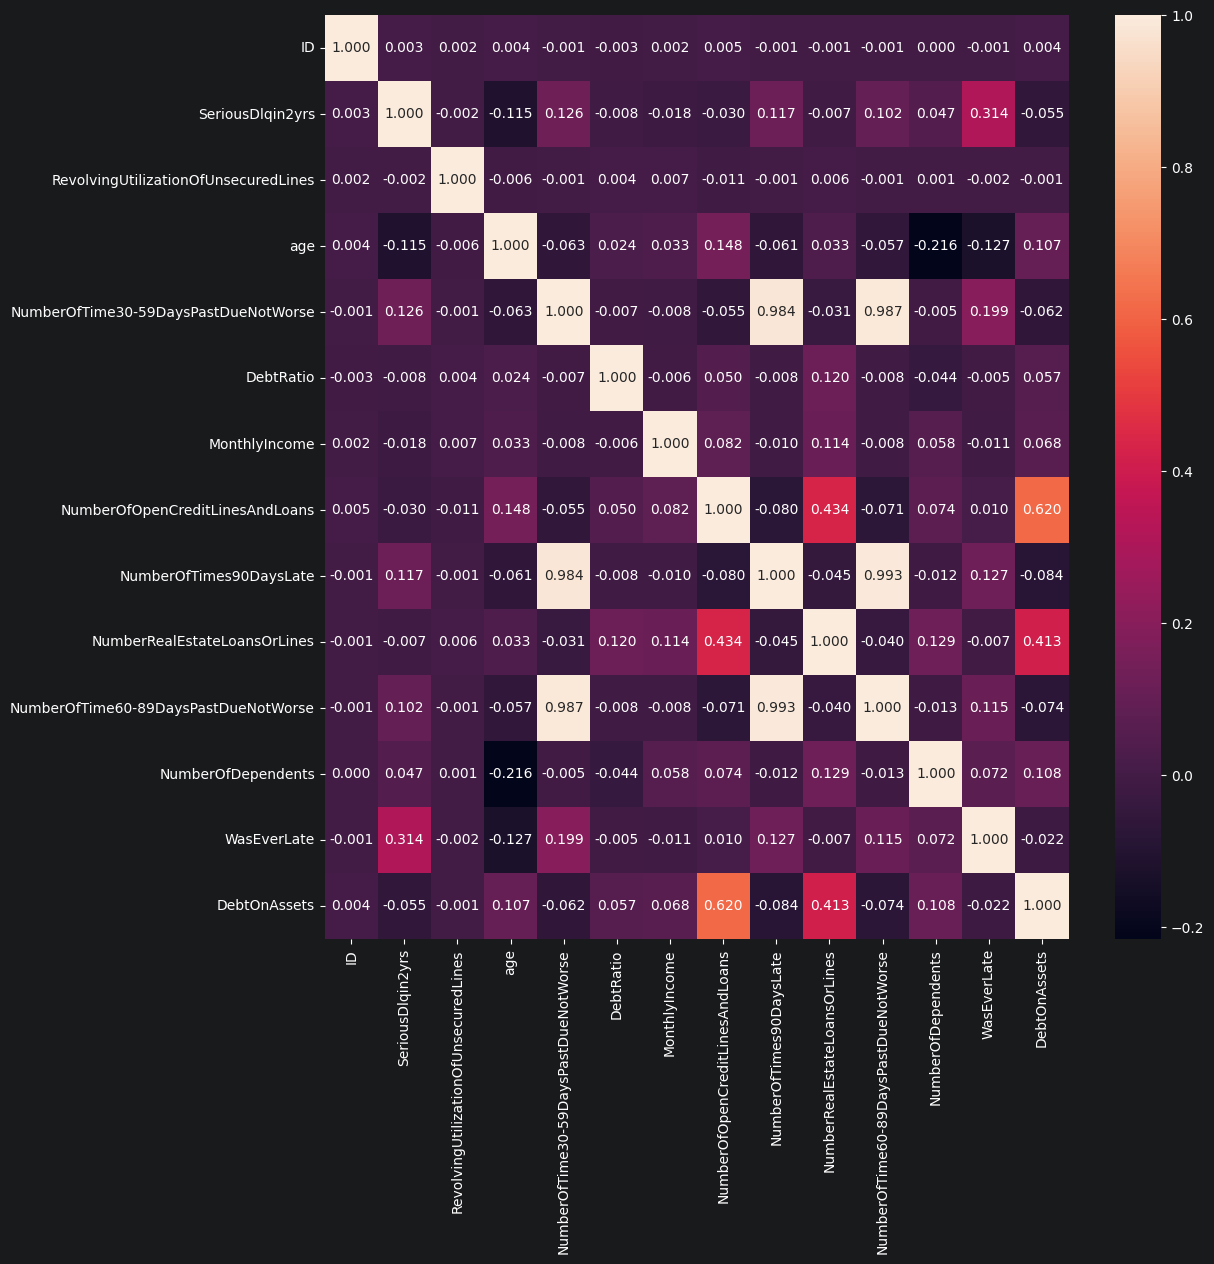

In [190]:
corr = df.corr()
plt.figure(figsize=(12,12))
sns.heatmap(corr, annot=True, fmt='.3f')

In [191]:
df.describe()

,ID,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,WasEverLate,DebtOnAssets
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.500000e+05,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,75000.500000,0.066840,6.048438,52.295553,0.421033,353.005076,6.668124e+03,8.452760,0.265973,1.018240,0.240387,0.737413,0.202420,0.742500
std,43301.414527,0.249746,249.755371,14.771249,4.192781,2037.818523,1.288045e+04,5.145951,4.169304,1.129771,4.155179,1.107021,0.401805,0.437259
min,1.000000,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.903000e+03,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,6.600000e+03,8.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,7.400000e+03,11.000000,0.000000,2.000000,0.000000,1.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000,1.000000,1.000000


Now we can drop columns which will not provide additional information for the model

In [192]:
df = df.drop(columns=['ID', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfOpenCreditLinesAndLoans'])

<Axes: >

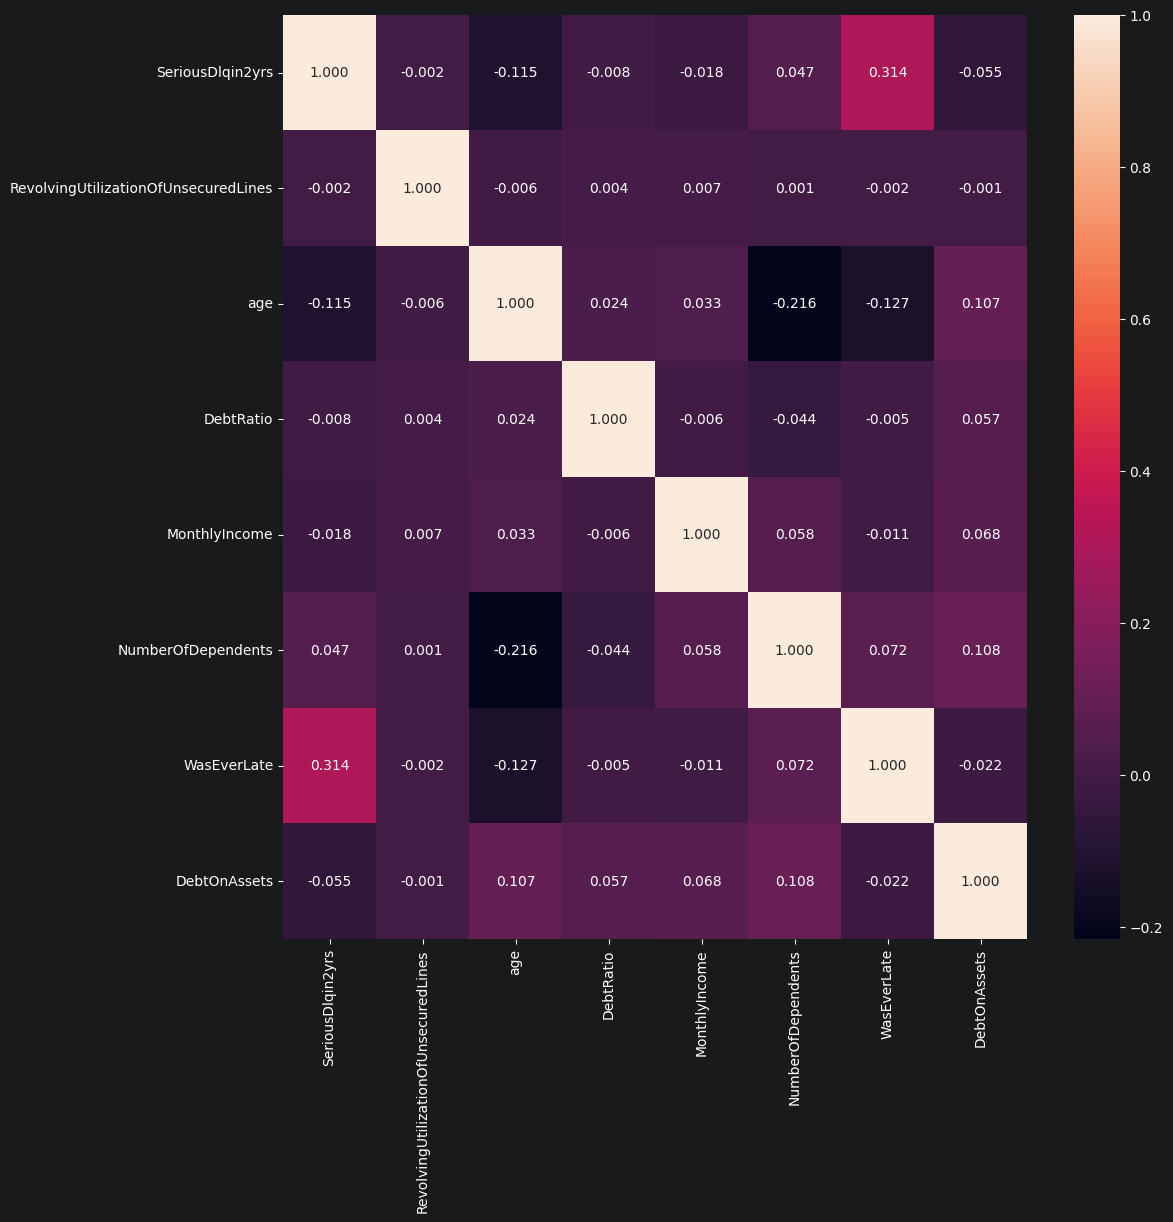

In [193]:
corr = df.corr()
plt.figure(figsize=(12,12))
sns.heatmap(corr, annot=True, fmt='.3f')

In [194]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 8 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   DebtRatio                             150000 non-null  float64
 4   MonthlyIncome                         150000 non-null  float64
 5   NumberOfDependents                    150000 non-null  int64  
 6   WasEverLate                           150000 non-null  int64  
 7   DebtOnAssets                          150000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 9.2 MB


In [195]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,DebtRatio,MonthlyIncome,NumberOfDependents,WasEverLate,DebtOnAssets
count,150000.000000,150000.000000,150000.000000,150000.000000,1.500000e+05,150000.000000,150000.000000,150000.000000
mean,0.066840,6.048438,52.295553,353.005076,6.668124e+03,0.737413,0.202420,0.742500
std,0.249746,249.755371,14.771249,2037.818523,1.288045e+04,1.107021,0.401805,0.437259
min,0.000000,0.000000,21.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.175074,3.903000e+03,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.366508,6.600000e+03,0.000000,0.000000,1.000000
75%,0.000000,0.559046,63.000000,0.868254,7.400000e+03,1.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,329664.000000,3.008750e+06,20.000000,1.000000,1.000000


### Remarks
The correlation matrix shows that most features are weakly correlated with each other. This is beneficial for many machine learning models, as highly correlated features can negatively impact model stability and interpretability.

The strongest correlation is between SeriousDlqin2yrs and WasEverLate (correlation ≈ 0.31). It suggests that individuals who were late on payments in the past are more likely to experience serious delinquency.

All other correlations are close to zero, implying that most variables provide relatively independent information.